In [70]:
#!pip3 install kagglehub --upgrade --user --quiet

In [71]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")

### Data Loading

In [72]:
def load_data(test=False):
    path = kagglehub.dataset_download("prakharrathi25/banking-dataset-marketing-targets")
    df = pd.read_csv(f"{path}/train.csv", sep=';')
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

In [73]:
train_df = load_data()

Dataset loaded: 45211 rows, 17 columns.


### Data Inspection

In [74]:
def get_dataset_summary(df):
    """
    Performs basic dataset exploration: types, nulls, and 'unknown' values.
    Reflects the 'inspect before training' goal from Lab 1.
    """
    print(f"--- Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns ---")
    
    # 1. Inspect Data Types (Important for determining encoding strategies)
    print("\n--- Feature Data Types ---")
    print(df.dtypes)
    
    # 2. Check for standard NaNs (Though this dataset typically uses 'unknown')
    print("\n--- Standard Missing Values (NaNs) ---")
    print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "No standard NaNs found.")
    
    # 3. Check for 'unknown' strings (The dataset's specific way of marking missing data)
    print("\n--- 'Unknown' Value Counts per Column ---")
    found_unknown = False
    for col in df.columns:
        # Check if 'unknown' exists in the column
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            percentage = (unknown_count / len(df)) * 100
            print(f"{col:12}: {unknown_count:>5} values ({percentage:.2f}%)")
            found_unknown = True
            
    if not found_unknown:
        print("No 'unknown' values detected.")

def analyze_outliers(df):
    """
    Identifies outliers using the IQR method from Lab 1.
    Calculates the percentage of data points that fall outside the bounds.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("--- Outlier Analysis (IQR Method) ---")
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        percentage = (len(outliers) / len(df)) * 100
        
        print(f"{col:10}: {len(outliers):>5} outliers ({percentage:.2f}%)")

In [75]:
get_dataset_summary(train_df)
analyze_outliers(train_df)

--- Dataset Dimensions: 45211 rows, 17 columns ---

--- Feature Data Types ---
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

--- Standard Missing Values (NaNs) ---
No standard NaNs found.

--- 'Unknown' Value Counts per Column ---
job         :   288 values (0.64%)
education   :  1857 values (4.11%)
contact     : 13020 values (28.80%)
poutcome    : 36959 values (81.75%)
--- Outlier Analysis (IQR Method) ---
age       :   487 outliers (1.08%)
balance   :  4729 outliers (10.46%)
day       :     0 outliers (0.00%)
duration  :  3235 outliers (7.16%)
campaign  :  3064 outliers (6.78%)
pdays     :  8257 outliers (18.26%)
previous  :  8257 outliers (18.26%)


### Visualization

In [ ]:
def plot_target_distribution(df):
    """
    Visualizes class imbalance using a Pie Chart.
    As seen in Lab 5, identifying imbalance is critical for choosing metrics.
    """
    plt.figure(figsize=(8, 6))
    counts = df['y'].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
            startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.1, 0))
    plt.title('Target Variable: Subscription Success Rate')
    plt.show()

def plot_numeric_distributions(df):
    """
    Expanded numeric check. Showing 4 is okay, but adding 'pdays' and 'previous' 
    helps identify patterns in contact frequency.
    """
    numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
    # Creating a 3x2 grid to accommodate more features
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {col.capitalize()}')
    
    plt.tight_layout()
    plt.show()

def plot_categorical_proportions(df, cat_col):
    """
    FIXED: Removed the '0 Axes' error by passing the ax object correctly.
    This helps identify which segments to target.
    """
    # Create the figure and axis first
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Calculate proportions
    prop_df = pd.crosstab(df[cat_col], df['y'], normalize='index') * 100
    
    # Plot directly onto the axis 'ax'
    prop_df.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax)
    
    ax.set_title(f'Subscription Success Percentage by {cat_col.capitalize()}')
    ax.set_ylabel('Percentage %')
    plt.xticks(rotation=45)
    plt.legend(title='Subscribed?', labels=['No', 'Yes'], loc='upper right')
    plt.show()

def plot_correlation_heatmap(df):
    """
    Visualizes relationships between numerical features.
    Helps identify multicollinearity before modeling.
    """
    plt.figure(figsize=(10, 8))
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

def plot_duration_impact(df):
    """
    Uses a boxplot to see the distribution of call duration for each outcome.
    Helps identify if there is a 'minimum time' needed for success.
    """
    plt.figure(figsize=(10, 6))
    # Fix: assign x to hue and set legend=False to suppress the warning
    sns.boxplot(x='y', y='duration', data=df, hue='y', palette='Set2', legend=False)
    plt.yscale('log') 
    plt.title('Impact of Call Duration on Subscription (Log Scale)')
    plt.ylabel('Duration (seconds - Log Scale)')
    plt.xlabel('Subscribed?')
    plt.show()

def plot_debt_vs_conversion(df):
    """
    Bivariate analysis of housing/personal loans vs. target.
    Does existing debt prevent clients from investing in deposits?
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Housing Loan vs Target
    prop_housing = pd.crosstab(df['housing'], df['y'], normalize='index') * 100
    prop_housing.plot(kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#2ecc71'])
    ax1.set_title('Subscription Rate: Housing Loan Status')
    
    # Personal Loan vs Target
    prop_loan = pd.crosstab(df['loan'], df['y'], normalize='index') * 100
    prop_loan.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'])
    ax2.set_title('Subscription Rate: Personal Loan Status')
    
    plt.show()

def plot_campaign_efficiency(df):
    """
    Visualizes success rate based on the number of contacts in this campaign.
    Identifies the 'sweet spot' for resource allocation.
    """
    plt.figure(figsize=(12, 6))
    # Group by number of contacts and calculate mean 'yes' (1) vs 'no' (0)
    # First, convert 'y' to numeric for calculation
    temp_df = df.copy()
    temp_df['y_numeric'] = temp_df['y'].map({'yes': 1, 'no': 0})
    
    efficiency = temp_df.groupby('campaign')['y_numeric'].mean() * 100
    efficiency.head(10).plot(kind='line', marker='o', color='purple')
    
    plt.title('Conversion Rate % by Number of Contacts (Campaign)')
    plt.xlabel('Number of Contacts during this Campaign')
    plt.ylabel('Success Rate (%)')
    plt.grid(True)
    plt.show()


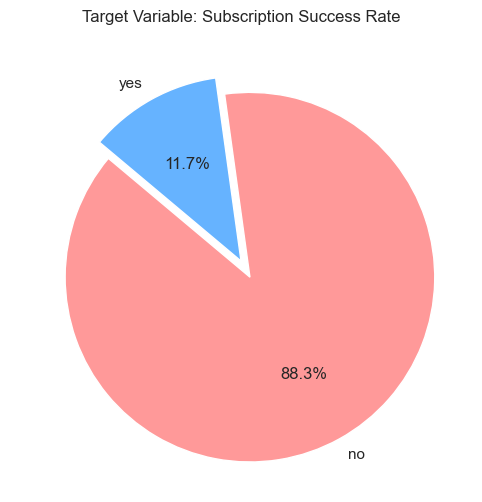

In [ ]:
# Class Imbalance (Pie Chart)
plot_target_distribution(train_df)

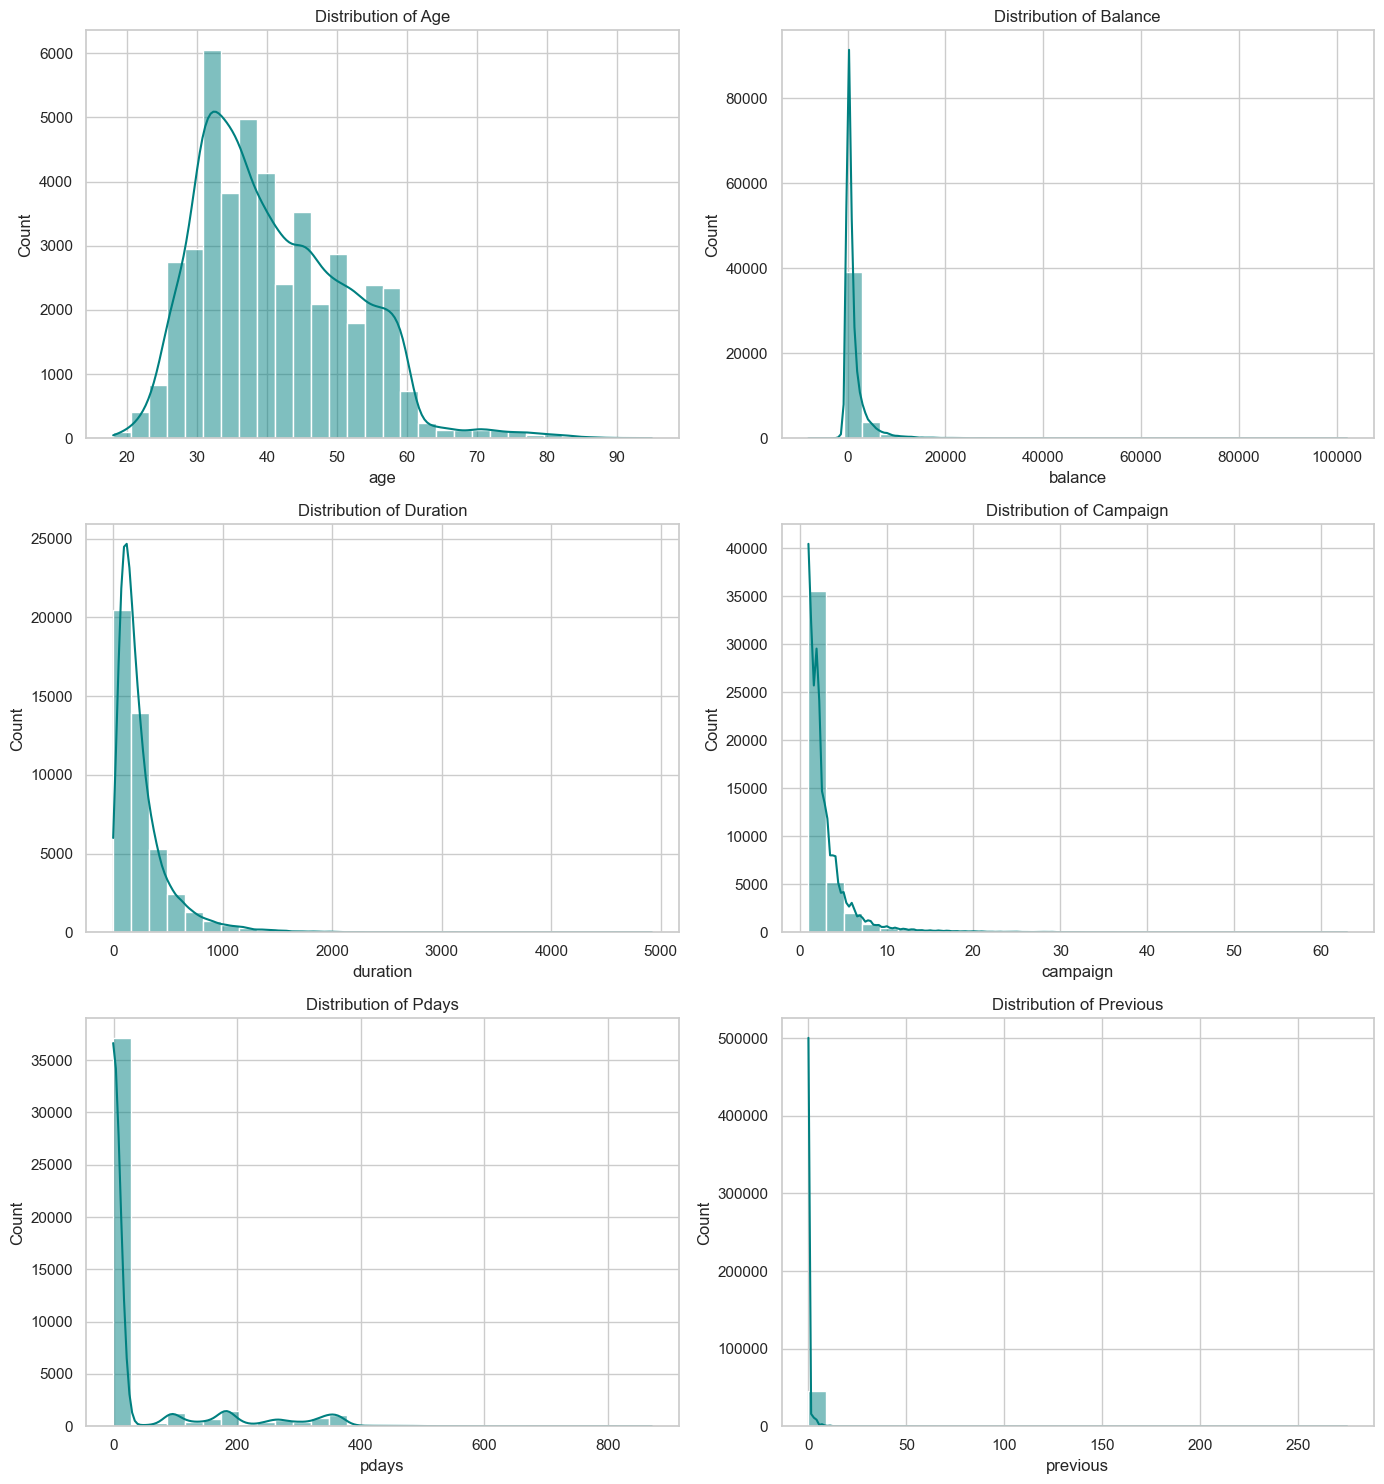

In [ ]:
# Numeric Distributions 
plot_numeric_distributions(train_df)

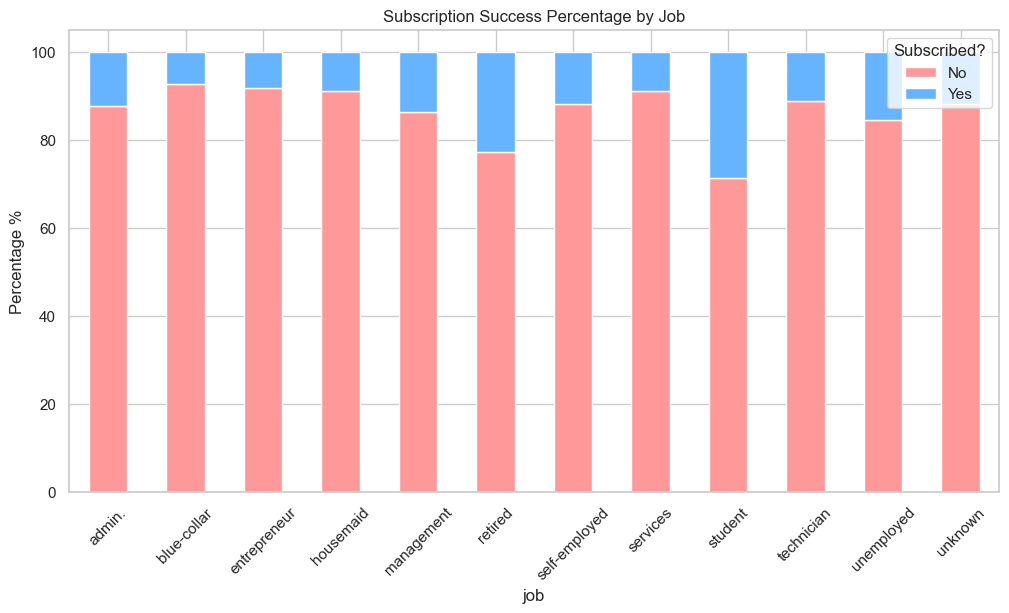

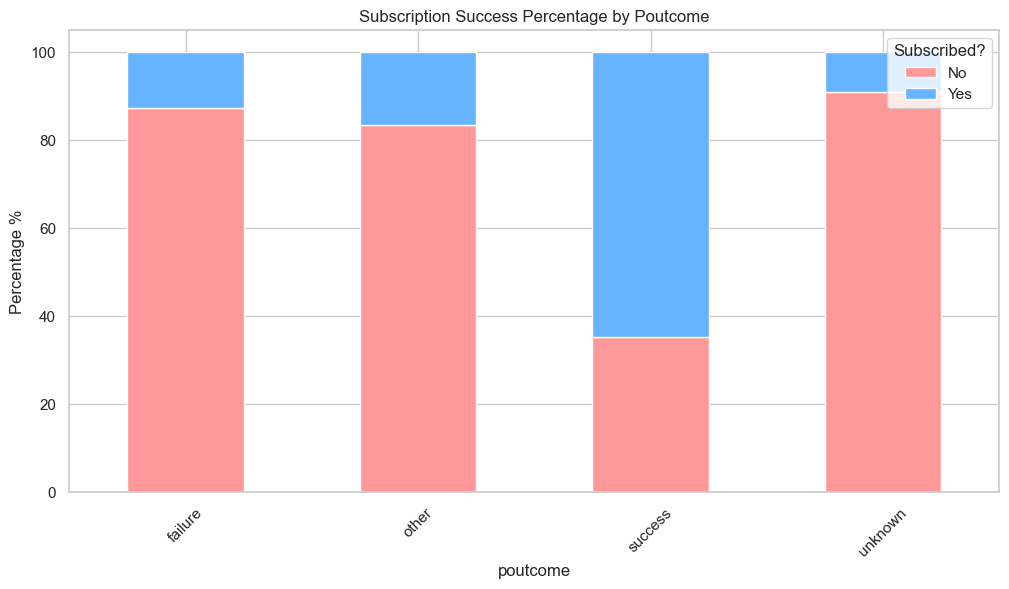

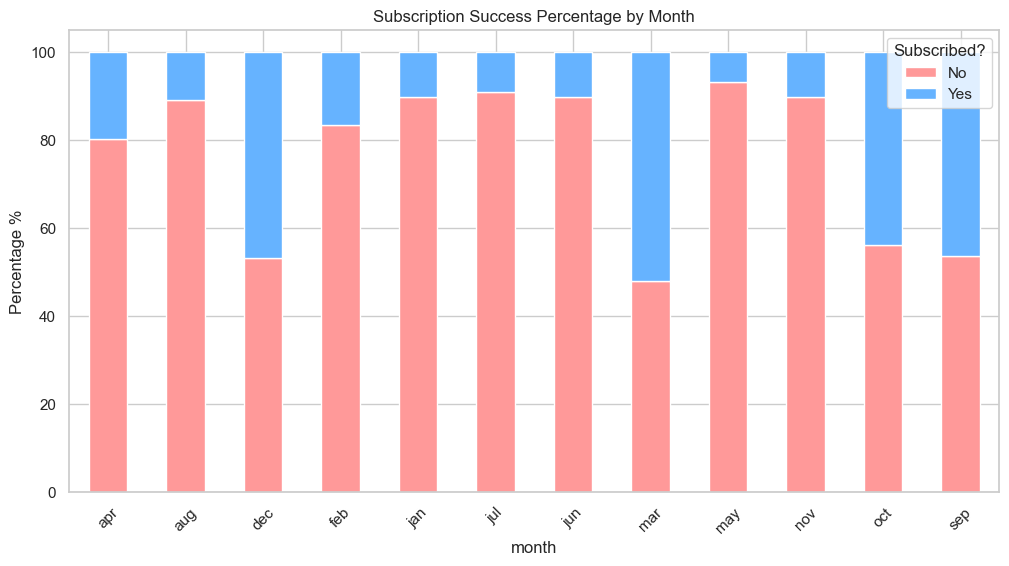

In [ ]:
# 3. Categorical Analysis 
plot_categorical_proportions(train_df, 'job')
plot_categorical_proportions(train_df, 'poutcome') 
plot_categorical_proportions(train_df, 'month') 

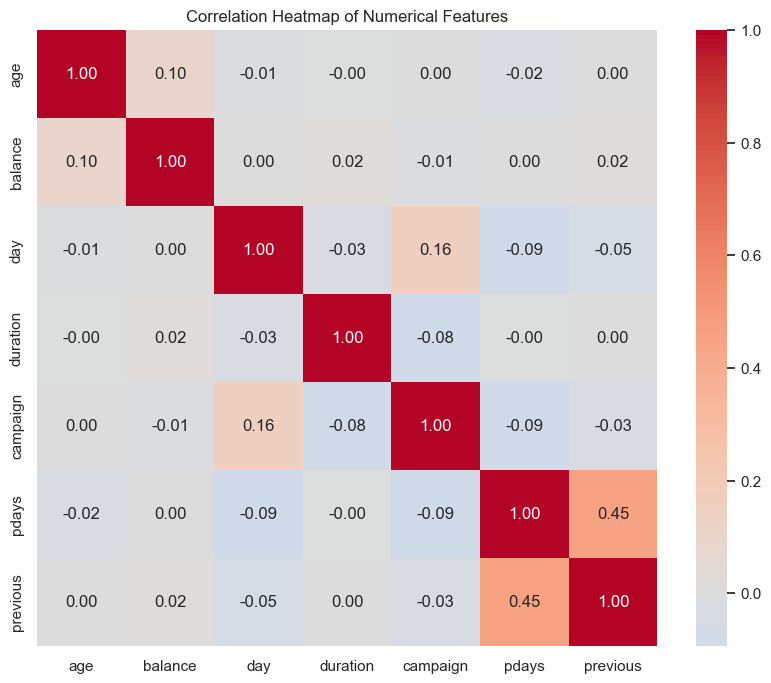

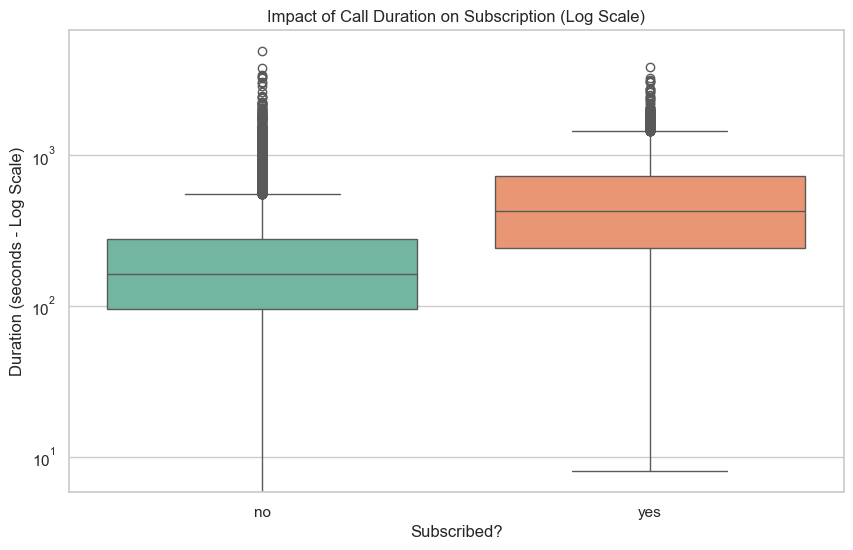

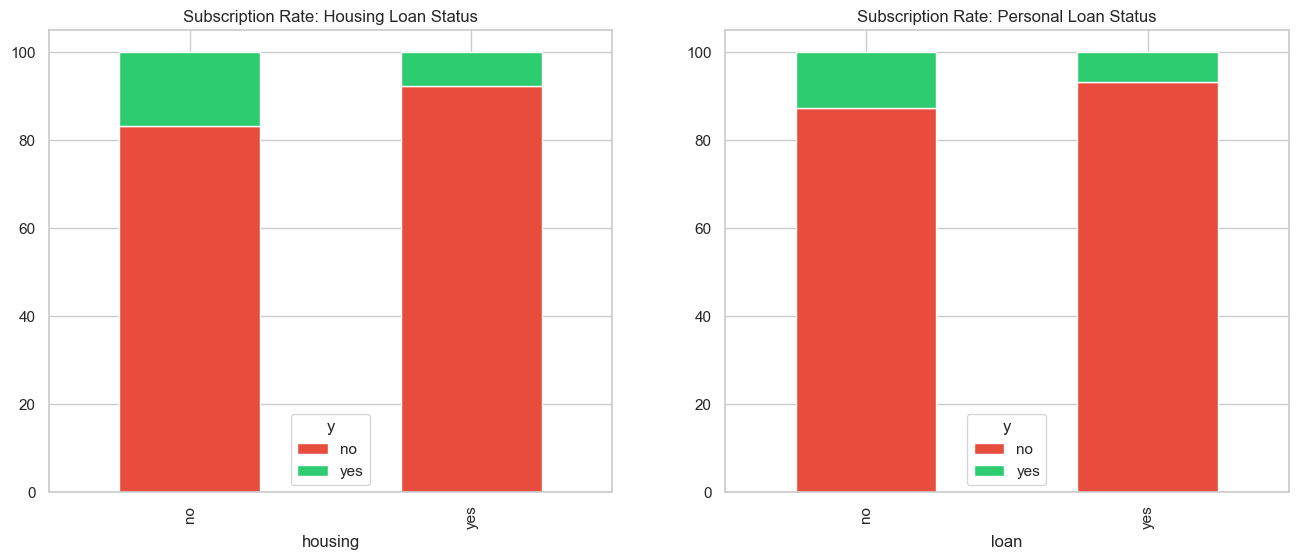

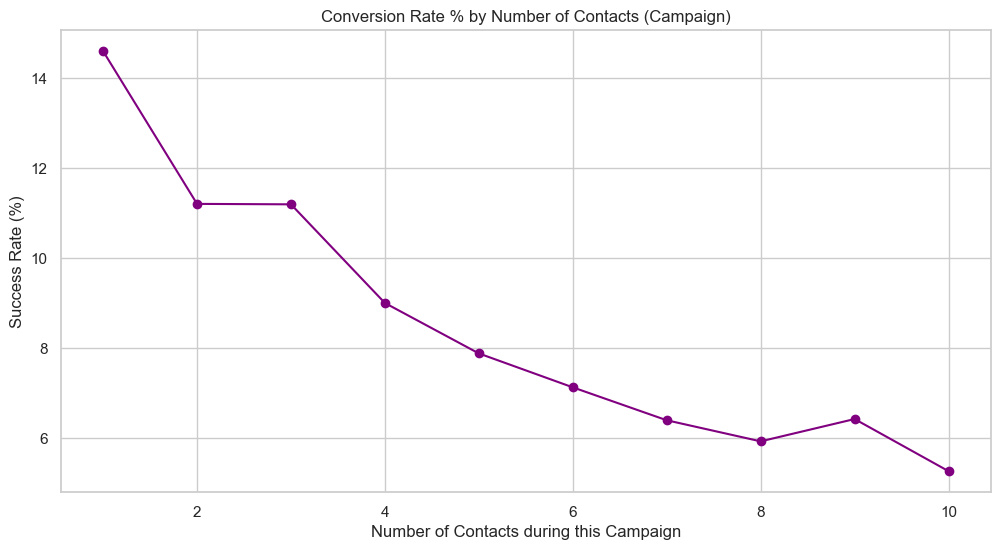

In [ ]:
# 4. Advanced Insights 
plot_correlation_heatmap(train_df)
plot_duration_impact(train_df)
plot_debt_vs_conversion(train_df)
plot_campaign_efficiency(train_df)

### Preprocessing

In [ ]:
# Preprocessing structure through pipeline
def preprocess_data(df):
  # Missing Removal
  rows_not_missing = df.total_bedrooms.notna()
  rows_missing = df.total_bedrooms.isna()
  df_without_missings = df[rows_not_missing]
  knn = KNeighborsClassifier(n_neighbors=1)
  knn.fit(df_without_missings, df.total_bedrooms[rows_not_missing])
  imputed_values = knn.predict(df[rows_missing]);
  df.loc[rows_missing, 'total_bedrooms'] = imputed_values

  # Ourlier Removal
  numeric_df = df.select_dtypes(include=np.number)
  Q1 = numeric_df.quantile(0.25, numeric_only=True)
  Q3 = numeric_df.quantile(0.75, numeric_only=True)
  IQR = Q3 - Q1
  for col in numeric_df.columns:
      lower_bound = Q1[col] - 1.5 * IQR[col]
      upper_bound = Q3[col] + 1.5 * IQR[col]
      df[col] = np.clip(df[col], lower_bound, upper_bound)

  # Adding features
  housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
  housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']
  housing['population_per_household'] = housing['population'] / housing['households']

  # Categorical Encoding
  housing_cat = housing[['ocean_proximity']]
  housing_dummies = pd.get_dummies(housing_cat, prefix='ocean_proximity', dtype=int)
  housing = pd.concat([housing.drop('ocean_proximity', axis=1), housing_dummies], axis=1)

  # Numerical Transformation
  std_scaler = preprocessing.StandardScaler()
  housing[housing.columns] = std_scaler.fit_transform(housing[housing.columns])

  return housing

# df = pipeline("housing.csv")
# df.head()


NameError: name 'df' is not defined

In [ ]:
def complete_pipeline():
    train_df = load_data(test=False)
    # Preprocessing
    # Models Comparison
    # Evaluation